<a href="https://colab.research.google.com/github/milkmaN4123/Data_bases_Cw_northstar/blob/clean/SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages("DBI")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
library(ggplot2)

In [7]:
install.packages("readr")
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
install.packages("sqldf")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [9]:
library(sqldf)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [10]:
install.packages("rio")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’, ‘writexl’, ‘R.utils’




In [11]:
install.packages("RCurl")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’




In [12]:
hubs <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_hubs.csv"
complaints <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_complaints.csv"
customers <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_customers.csv"
deliveries <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_deliveries.csv"
drivers <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_drivers.csv"
incidents <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_incidents.csv"
orders <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_orders.csv"
vehicles <- "https://raw.githubusercontent.com/milkmaN4123/Data_bases_Cw_northstar/refs/heads/clean/clean/clean_vehicles.csv"


In [13]:
con <- dbConnect(SQLite(), ":memory:")

In [14]:
#Create data frames from the cleaned csv stroed in github repo

df_hub <- data.frame(read_csv(hubs))
dbWriteTable(con, "hubs", df_hub, overwrite = TRUE)

df_customers <- data.frame(read_csv(customers))
dbWriteTable(con, "customers", df_customers, overwrite = TRUE)

df_drivers <- data.frame(read_csv(drivers))
dbWriteTable(con, "drivers", df_drivers, overwrite = TRUE)

df_vehicles <- data.frame(read_csv(vehicles))
dbWriteTable(con, "vehicles", df_vehicles, overwrite = TRUE)

df_orders <- data.frame(read_csv(orders))
dbWriteTable(con, "orders", df_orders, overwrite = TRUE)

df_deliveries <- data.frame(read_csv(deliveries))
dbWriteTable(con, "deliveries", df_deliveries, overwrite = TRUE)

df_incidents <- data.frame(read_csv(incidents))
dbWriteTable(con, "incidents", df_incidents, overwrite = TRUE)

df_complaints <- data.frame(read_csv(complaints))
dbWriteTable(con, "complaints", df_complaints, overwrite = TRUE)


Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 617 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
date (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 163 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): driver_id, base_zone, employment_type, shift_preference
dbl (3): years_experience, training_score, driver_rating


In [15]:
head(df_deliveries)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,missing_proof,delivery_duration_hours
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<time>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,dl00001,o00938,d004,v056,h05,18/06/2024 10:57,05:59:00,failed,17.26,1,FALSE,3.07,12.05,0,22.15
2,dl00002,o00004,d138,v007,h02,11/01/2025 18:45,39:00:00,ontime,10.34,1,FALSE,5.00,13.41,0,-1.10
3,dl00003,o00639,d006,v049,h02,02/06/2025 20:39,45:32:00,ontime,7.92,0,FALSE,4.98,8.51,0,1.11
4,dl00004,o00313,d116,v055,h02,08/03/2024 23:31,30:08:00,delayed,16.42,0,FALSE,4.18,13.62,0,23.99
5,dl00005,o00844,d108,v034,h01,21/09/2025 11:43,45:34:00,ontime,14.52,1,FALSE,4.18,9.22,0,4.04
6,dl00006,o00029,d037,v098,h03,11/09/2024 12:40,11:52:00,delayed,13.84,0,FALSE,1.57,9.58,0,28.53


In [47]:
summary(df_deliveries$customer_rating_post_delivery)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.360   4.040   3.869   4.560   5.000 

In [16]:
poor_deliveries <- sqldf("SELECT delivery_id, order_id, hub_id, delivery_status AS status, missing_proof, delivery_duration_hours
FROM df_deliveries
WHERE 	delivery_duration_hours < 0 ")

print(poor_deliveries)

   delivery_id order_id hub_id status missing_proof delivery_duration_hours
1      dl00002   o00004    h02 ontime             0                   -1.10
2      dl00011   o00202    h04 ontime             0                   -0.67
3      dl00018   o00611    h01 ontime             0                   -0.96
4      dl00029   o00723    h07 ontime             0                   -2.18
5      dl00031   o00830    h01 ontime             0                   -0.17
6      dl00047   o00263    h06 ontime             0                   -0.35
7      dl00050   o00534    h06 ontime             0                   -1.65
8      dl00061   o00635    h08 ontime             0                   -1.26
9      dl00065   o01234    h01 ontime             0                   -0.04
10     dl00091   o00941    h04 ontime             0                   -0.26
11     dl00095   o00416    h08 ontime             0                   -1.38
12     dl00111   o00105    h06 ontime             0                   -0.56
13     dl001

In [17]:
head(df_orders)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<lgl>
1,o00001,c0292,passenger,20/08/2024,6,airport,south,medium,126.65,app,FALSE
2,o00002,c0459,passenger,14/05/2024,24,north,airport,low,109.30,app,FALSE
3,o00003,c0161,passenger,02/09/2025,4,west,airport,high,33.50,phone,FALSE
4,o00004,c0520,parcel,11/01/2025,2,riverside,north,medium,10.04,app,TRUE
5,o00005,c0558,retail,17/02/2025,12,riverside,south,low,125.58,phone,FALSE
6,o00006,c0437,retail,05/08/2024,1,central,east,high,151.44,web,TRUE


In [18]:
late_orders <- sqldf("
  SELECT
    o.order_id,
    o.promised_window_hours,
    d.delivery_duration_hours
  FROM df_orders o
  INNER JOIN df_deliveries d
    ON o.order_id = d.order_id
  WHERE d.delivery_duration_hours > o.promised_window_hours
")

print(late_orders)

    order_id promised_window_hours delivery_duration_hours
1     o00003                     4                    8.86
2     o00007                     2                    8.92
3     o00022                    12                   19.90
4     o00023                     4                   22.44
5     o00025                     6                    7.07
6     o00027                     4                    4.48
7     o00029                    24                   28.53
8     o00031                    24                   28.59
9     o00033                     6                   16.98
10    o00035                     4                   14.03
11    o00036                     4                    6.02
12    o00042                    24                   37.10
13    o00052                    12                   16.12
14    o00055                     2                    4.09
15    o00056                     4                    4.15
16    o00058                     2                    2.

In [19]:
mean_delay <- sqldf(" SELECT AVG(delivery_duration_hours) AS average_delay FROM late_orders")

print(mean_delay)

  average_delay
1       13.4901


In [20]:
zone_distances <- sqldf("
  SELECT
    o.order_id, o.pickup_zone	, o.dropoff_zone, d.route_distance_km
  FROM df_orders o
  LEFT JOIN df_deliveries d
    ON d.order_id = o.order_id
    ORDER BY route_distance_km DESC
")

print(zone_distances)


     order_id pickup_zone dropoff_zone route_distance_km
1      o00738     airport         west             41.94
2      o00753     airport    riverside             40.68
3      o00297     airport    riverside             40.23
4      o00128     airport      airport             40.11
5      o00120     airport        north             39.90
6      o01169     airport         east             38.25
7      o01107     airport      central             37.41
8      o00621     airport      airport             37.21
9      o00055     airport    riverside             37.02
10     o01246     airport        north             36.94
11     o00521     airport        south             36.28
12     o00352     airport        north             36.08
13     o00474     airport      central             35.40
14     o00017     airport        south             35.33
15     o01000     airport         west             35.25
16     o00819     airport         west             35.07
17     o00308     airport      

In [21]:
summary(df_orders)

      order_id       customer_id      service_type   order_created_at
 Length   :1225   Length   :1225   Length   :1225   Length   :1225   
 N.unique :1225   N.unique : 562   N.unique :   5   N.unique : 592   
 N.blank  :   0   N.blank  :   0   N.blank  :   0   N.blank  :   0   
 Min.nchar:   6   Min.nchar:   5   Min.nchar:   6   Min.nchar:  10   
 Max.nchar:   6   Max.nchar:   5   Max.nchar:   9   Max.nchar:  10   
                                                                     
 promised_window_hours    pickup_zone      dropoff_zone    priority_level
 Min.   : 1.000        Length   :1225   Length   :1225   Length   :1225  
 1st Qu.: 4.000        N.unique :   8   N.unique :   8   N.unique :   4  
 Median : 6.000        N.blank  :   0   N.blank  :   0   N.blank  :   0  
 Mean   : 7.668        Min.nchar:   3   Min.nchar:   3   Min.nchar:   3  
 3rd Qu.:12.000        Max.nchar:   9   Max.nchar:   9   Max.nchar:   8  
 Max.   :24.000                                                   

In [22]:
head(df_complaints)

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>,<dbl>,<dbl>
1,cp0001,c0464,o00814,appissue,app,high,2025-03-30,open,11,23.99
2,cp0002,c0056,o00628,missedpickup,phone,medium,2024-11-07,open,4,21.64
3,cp0003,c0469,o00384,delay,chatbot,high,2024-01-02,open,16,26.41
4,cp0004,c0631,o00406,delay,app,medium,2025-01-14,awaitingcustomer,7,23.44
5,cp0005,c0535,o00154,delay,email,medium,2024-08-31,resolved,1,16.18
6,cp0006,c0096,o00147,delay,app,medium,2024-07-22,resolved,9,18.51


In [23]:
summary(df_complaints)

    complaint_id    customer_id       order_id     complaint_type
 Length   :304   Length   :304   Length   :304   Length   :304   
 N.unique :304   N.unique :223   N.unique :270   N.unique :  7   
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0   
 Min.nchar:  6   Min.nchar:  5   Min.nchar:  6   Min.nchar:  5   
 Max.nchar:  6   Max.nchar:  5   Max.nchar:  6   Max.nchar: 17   
                                                                 
      channel         severity     created_at               status   
 Length   :304   Length   :304   Min.   :2024-01-02   Length   :304  
 N.unique :  4   N.unique :  3   1st Qu.:2024-06-25   N.unique :  4  
 N.blank  :  0   N.blank  :  0   Median :2024-11-30   N.blank  :  0  
 Min.nchar:  3   Min.nchar:  3   Mean   :2024-12-09   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   3rd Qu.:2025-05-20   Max.nchar: 16  
                                 Max.   :2026-01-07                  
 resolution_days  compensation_amount
 Min.   : 

In [24]:
head(df_customers)

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<chr>,<chr>
1,c0001,26,north,sme,2024-11-27,44.9,69.2,app,active
2,c0002,61,airport,consumer,2025-10-28,55.4,66.6,app,active
3,c0004,75,central,consumer,2025-08-19,32.5,33.0,app,active
4,c0005,26,riverside,consumer,2025-06-03,55.9,100.0,web,active
5,c0006,41,west,consumer,2024-03-29,39.9,43.3,web,active
6,c0007,54,west,consumer,2024-03-12,36.1,39.0,app,active


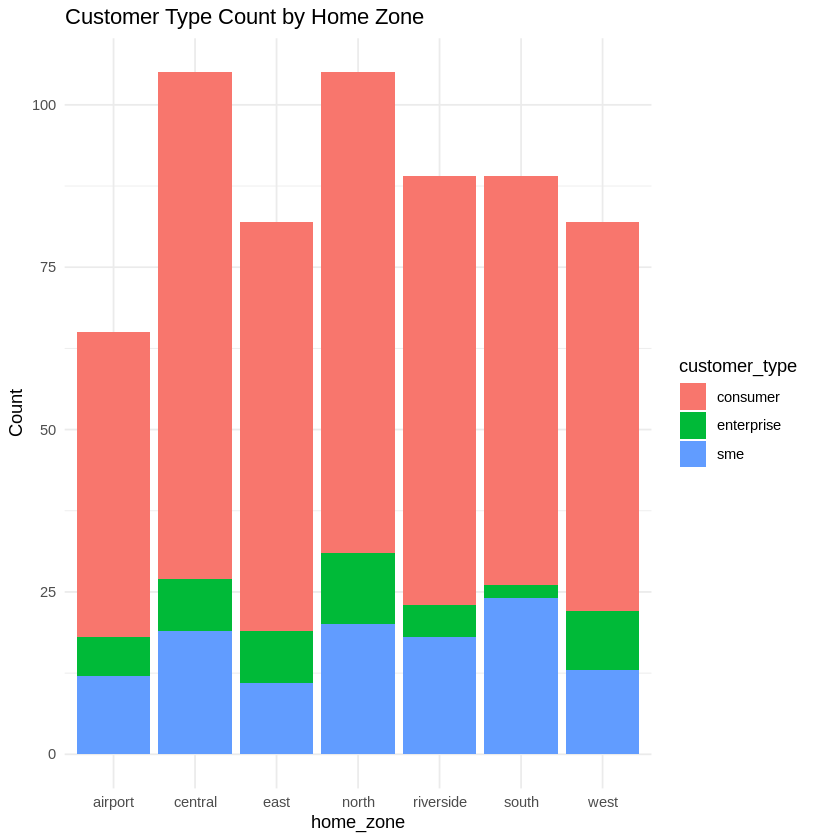

In [25]:
ggplot(df_customers, aes(x = home_zone, fill = customer_type)) +
  geom_bar() +
  labs(
    x = "home_zone",
    y = "Count",
    fill = "customer_type",
    title = "Customer Type Count by Home Zone"
  ) +
  theme_minimal()

In [26]:
profit_by_zone <- sqldf("
  SELECT
    c.home_zone,
    SUM(o.total_order_value) - SUM(COALESCE(d.total_fuel_cost, 0)) AS total_profit
  FROM (
    SELECT customer_id, order_id, SUM(order_value) AS total_order_value
    FROM df_orders
    GROUP BY customer_id, order_id
  ) o
  INNER JOIN df_customers c
    ON o.customer_id = c.customer_id
  LEFT JOIN (
    SELECT order_id, SUM(fuel_or_charge_cost) AS total_fuel_cost
    FROM df_deliveries
    GROUP BY order_id
  ) d
    ON o.order_id = d.order_id
  GROUP BY c.home_zone
  ORDER BY total_profit DESC
")

print(profit_by_zone)

  home_zone total_profit
1   central     17753.42
2     north     15948.19
3      east     13560.57
4 riverside     13128.36
5      west     13016.78
6     south     12404.04
7   airport      9592.54


In [27]:
head(df_drivers)

,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,d001,airport,fulltime,8,67.8,3.54,morning,TRUE
2,d002,central,fulltime,4,42.4,3.94,evening,TRUE
3,d003,airport,fulltime,11,96.5,5.00,evening,TRUE
4,d004,airport,parttime,13,88.9,4.75,morning,TRUE
5,d005,north,fulltime,3,69.7,4.14,morning,TRUE
6,d006,central,fulltime,8,78.8,4.38,flexible,TRUE


In [28]:
head(df_hub)

,hub_id,hub_name,zone,hub_type,capacity_score
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,h01,north exchange,north,dispatch,82
2,h02,south link,south,dispatch,78
3,h03,east dock,east,warehouse,74
4,h04,west gate,west,dispatch,69
5,h05,central core,central,control,88
6,h06,airport hub,airport,dispatch,71


In [29]:
head(df_incidents)

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,i0001,dl00221,batteryalert,11/03/2024,medium,escalated,12.3
2,i0002,dl00578,batteryalert,21/02/2024,low,open,9.6
3,i0003,dl00175,temperatureissue,17/04/2025,medium,open,22.0
4,i0004,dl00417,proofmissing,09/02/2025,medium,closed,9.8
5,i0005,dl00897,routedeviation,04/01/2025,low,open,13.0
6,i0006,dl00634,customernoshow,08/08/2025,high,pendingvendor,19.9


In [50]:
incident_counts <- sqldf("
  SELECT
    incident_type,
    COUNT(*) AS incident_count
  FROM df_incidents
  GROUP BY incident_type
  ORDER BY incident_count DESC
")

print(incident_counts)

     incident_type incident_count
1   customernoshow             42
2   routedeviation             41
3     proofmissing             40
4     vehiclefault             36
5     batteryalert             34
6 temperatureissue             29
7     appsyncerror             28
8   safetynearmiss             13


In [30]:
head(df_vehicles)

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,v001,ev,north,28/12/2024,71.8,56928,active,v2.2
2,v002,ev,airport,21/04/2024,67.9,159368,inrepair,v2.2
3,v003,cargovan,north,24/11/2025,91.7,219359,active,v2.1
4,v005,cargovan,west,15/11/2025,58.6,146638,active,v2.2
5,v006,ev,central,22/11/2025,78.6,141381,active,v2.1
6,v007,diesel,airport,17/09/2025,68.6,78468,active,v2.2


In [31]:
zone_milage <- sqldf("SELECT assigned_zone , AVG(odometer_km) AS milage FROM df_vehicles GROUP BY assigned_zone ORDER BY milage DESC")

print(zone_milage)

  assigned_zone   milage
1          west 147241.4
2     riverside 133967.7
3       airport 121341.2
4         north 112556.6
5       central 103703.1
6          east 102157.7
7         south 100598.1


In [32]:
complaints_by_channel <- sqldf("SELECT channel, COUNT(*) AS complaint FROM df_complaints GROUP BY channel")

print(complaints_by_channel)

  channel complaint
1     app        93
2 chatbot        63
3   email        60
4   phone        88


In [43]:
failed_manual_deliveries <- sqldf("SELECT COUNT(delivery_id) FROM df_deliveries WHERE delivery_status = 'failed' AND manual_route_override_count > 0")
failed_deliveries <- sqldf("SELECT COUNT(delivery_id) FROM df_deliveries WHERE delivery_status = 'failed'")

print(failed_manual_deliveries)
print(failed_deliveries)

  COUNT(delivery_id)
1                 83
  COUNT(delivery_id)
1                128


In [45]:
zones_multiple_overrides <- sqldf("
  SELECT
    h.zone,
    COUNT(DISTINCT d.delivery_id) AS deliveries_with_override
  FROM df_deliveries d
  LEFT JOIN df_hub h
    ON d.hub_id = h.hub_id
  WHERE d.manual_route_override_count > 1
  GROUP BY h.zone
  HAVING COUNT(DISTINCT d.delivery_id) > 1
  ORDER BY deliveries_with_override DESC
")

print(zones_multiple_overrides)

       zone deliveries_with_override
1   central                       64
2     north                       37
3 riverside                       31
4      west                       28
5      east                       27
6     south                       25
7   airport                       21


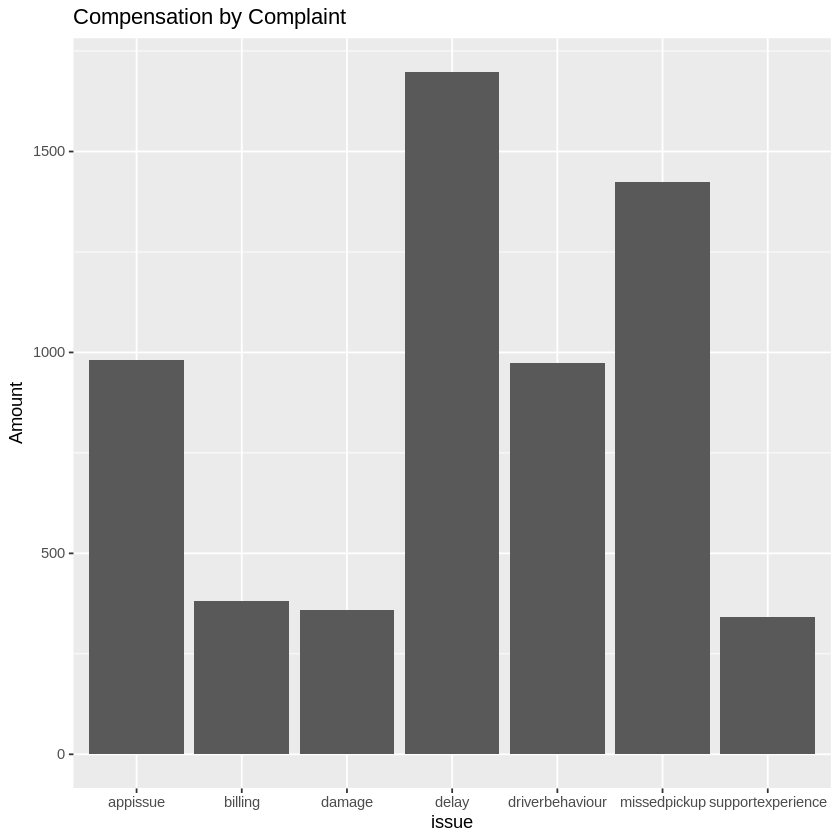

In [35]:
ggplot(df_complaints, aes(x = complaint_type, y = compensation_amount)) +
  geom_col() +
  labs(
    title = "Compensation by Complaint",
    x = "issue",
    y = "Amount"
  )

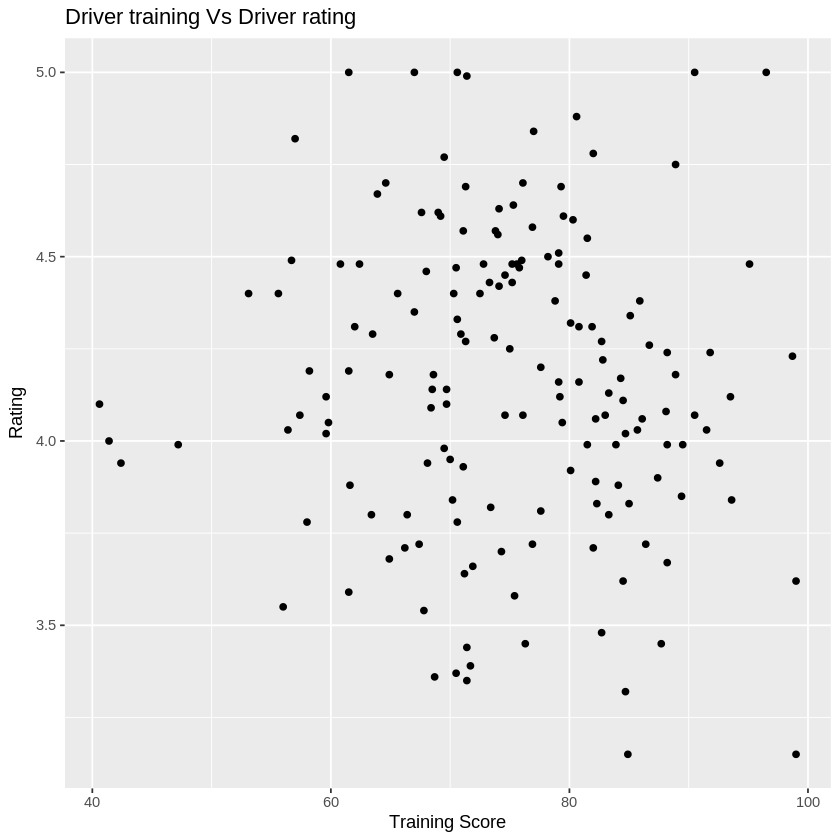

In [36]:
#Scatter plot to show correlation between training score for drivers and their rating

ggplot(df_drivers, aes(x = training_score, y = driver_rating)) +
  geom_point() +
  labs(
    title = "Driver training Vs Driver rating",
    x = "Training Score",
    y = "Rating"
  )

In [37]:
cor.test(df_drivers$training_score, df_drivers$driver_rating)


	Pearson's product-moment correlation

data:  df_drivers$training_score and df_drivers$driver_rating
t = -0.88848, df = 161, p-value = 0.3756
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.22119671  0.08477949
sample estimates:
        cor 
-0.06985133 


In [38]:
model <- lm(driver_rating ~ training_score, data = df_drivers)
summary(model)


Call:
lm(formula = driver_rating ~ training_score, data = df_drivers)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.98431 -0.26430 -0.00502  0.28910  0.89510 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     4.349583   0.216159  20.122   <2e-16 ***
training_score -0.002536   0.002854  -0.888    0.376    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4073 on 161 degrees of freedom
Multiple R-squared:  0.004879,	Adjusted R-squared:  -0.001302 
F-statistic: 0.7894 on 1 and 161 DF,  p-value: 0.3756


`geom_smooth()` using formula = 'y ~ x'


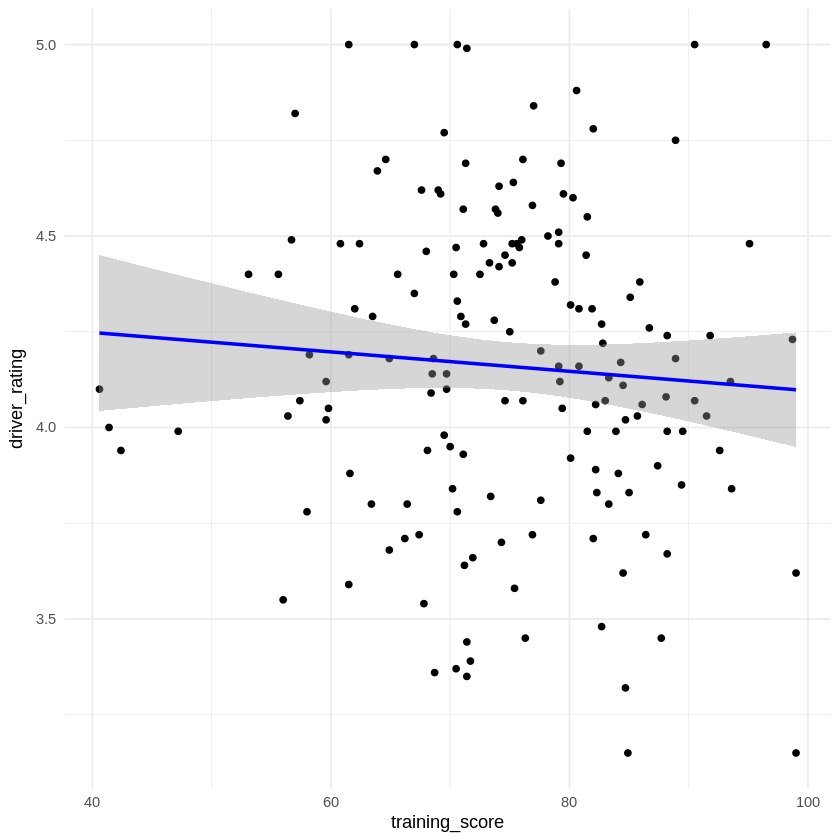

In [39]:
ggplot(df_drivers, aes(x = training_score, y = driver_rating)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  theme_minimal()

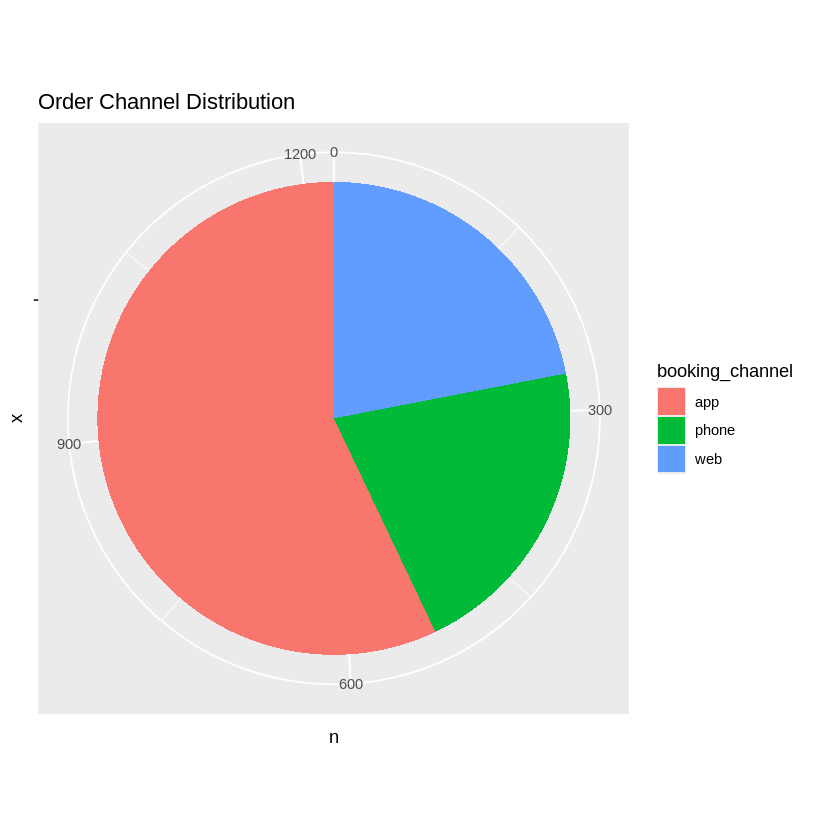

In [40]:
df_orders %>%
  count(booking_channel) %>%
  ggplot(aes(x = "", y = n, fill = booking_channel)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Order Channel Distribution")

In [41]:
vehicle_incident_risk <- sqldf("
  SELECT
    v.vehicle_id,
    i.incident_type,
    COUNT(*) AS incident_count
  FROM df_deliveries d
  INNER JOIN df_vehicles v
    ON d.vehicle_id = v.vehicle_id
  INNER JOIN df_incidents i
    ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, i.incident_type
  HAVING v.vehicle_id IN (
    SELECT
      d.vehicle_id
    FROM df_deliveries d
    INNER JOIN df_incidents i
      ON d.delivery_id = i.delivery_id
    GROUP BY d.vehicle_id
    HAVING COUNT(*) > 1
  )
  ORDER BY incident_count DESC
")

print(vehicle_incident_risk)

    vehicle_id    incident_type incident_count
1         v030     proofmissing              3
2         v047   routedeviation              3
3         v058     vehiclefault              3
4         v088     appsyncerror              3
5         v108     batteryalert              3
6         v109 temperatureissue              3
7         v005     appsyncerror              2
8         v009     proofmissing              2
9         v009   routedeviation              2
10        v014     vehiclefault              2
11        v020   customernoshow              2
12        v022     batteryalert              2
13        v024   routedeviation              2
14        v027   safetynearmiss              2
15        v036     appsyncerror              2
16        v039     appsyncerror              2
17        v042     vehiclefault              2
18        v043 temperatureissue              2
19        v047   customernoshow              2
20        v047     vehiclefault              2
21        v05